<a href="https://colab.research.google.com/github/QuinnCuijpers/DeepQ/blob/main/DeepQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installs


In [1]:
!pip install swig gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 46.7 MB/s eta 0:00:00


#Networks


In [2]:
from typing import override, cast

import torch as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


class DeepQNetwork(nn.Module):
    lr: float
    num_actions: int
    input_dims: int
    fc1_dims: int
    fc2_dims: int

    fc1: nn.Linear
    fc2: nn.Linear
    fc3: nn.Linear

    optimizer: optim.Optimizer
    loss: nn.MSELoss
    device: T.device

    def __init__(
        self, lr: float, input_dims: int, fc1_dims: int, fc2_dims: int, num_actions: int
    ):
        super().__init__()
        self.lr = lr
        self.input_dims = input_dims
        self.fc1_dims = fc1_dims
        self.fc2_dims = fc2_dims
        self.num_actions = num_actions
        self.fc1 = nn.Linear(self.input_dims, self.fc1_dims)
        self.fc2 = nn.Linear(self.fc1_dims, self.fc2_dims)
        self.fc3 = nn.Linear(self.fc2_dims, self.num_actions)
        self.optimizer = optim.Adam(self.parameters(), lr=self.lr)
        self.loss = nn.MSELoss()
        self.device = T.device("cuda:0" if T.cuda.is_available() else "cpu")
        _ = self.to(self.device)

    @override
    def forward(self, state: T.Tensor) -> T.Tensor:
        x = cast(T.Tensor, self.fc1(state))
        x = F.relu(x)
        x = cast(T.Tensor, self.fc2(x))
        x = F.relu(x)
        actions = cast(T.Tensor, self.fc3(x))

        return actions

#Agents

##Replay Buffer


In [3]:
import numpy as np

class ReplayBuffer:
    state_memory: np.ndarray[tuple[int, int], np.dtype[np.float32]]
    new_state_memory: np.ndarray[tuple[int, int], np.dtype[np.float32]]
    action_memory: np.ndarray[tuple[int], np.dtype[np.int32]]
    reward_memory: np.ndarray[tuple[int], np.dtype[np.float32]]
    terminal_memory: np.ndarray[tuple[int], np.dtype[np.bool]]
    mem_counter: int
    max_mem_size: int

    def __init__(self, mem_size: int, input_dims: int) -> None:
        self.max_mem_size = mem_size
        self.state_memory = np.zeros((mem_size, input_dims), dtype=np.float32)
        self.new_state_memory = np.zeros((mem_size, input_dims), dtype=np.float32)
        self.action_memory = np.zeros((mem_size), dtype=np.int32)
        self.reward_memory = np.zeros((mem_size), dtype=np.float32)
        self.terminal_memory = np.zeros((mem_size), dtype=np.bool)
        self.mem_counter = 0

    def store_transition(
        self,
        state: np.ndarray[tuple[int], np.dtype[np.float32]],
        action: int,
        reward: float,
        next_state: np.ndarray[tuple[int], np.dtype[np.float32]],
        done: bool,
    ):
        index = self.mem_counter % self.max_mem_size
        self.state_memory[index] = state
        self.new_state_memory[index] = next_state
        self.action_memory[index] = action
        self.reward_memory[index] = reward
        self.terminal_memory[index] = done
        self.mem_counter += 1

    def sample(self, batch_size: int):
        mem_size = min(self.max_mem_size, self.mem_counter)
        batch = np.random.choice(mem_size, batch_size, replace=False)

        states = self.state_memory[batch]
        next_states = self.new_state_memory[batch]
        actions = self.action_memory[batch]
        rewards = self.reward_memory[batch]
        terminal = self.terminal_memory[batch]

        return states, actions, rewards, next_states, terminal

##Epsilon Decayer

In [4]:
from typing import Callable

class EpsilonDecayer:
    eps_end: float
    decay_func: Callable[[float], float]

    def __init__(
        self, decay: Callable[[float], float] = lambda x: x - 5e-4, min: float = 0.01
    ) -> None:
        self.decay_func = decay
        self.eps_end = min

    def decay(self, epsilon: float) -> float:
        new_eps = self.decay_func(epsilon)
        return max(self.eps_end, new_eps)

##HyperParameters

In [5]:
from dataclasses import dataclass

@dataclass
class AgentHyperParameters:
    gamma: float = 0.99
    lr: float = 0.003
    batch_size: int = 64
    eps_end: float = 0.01
    eps_dec: float = 5e4
    replace_target_count: int = 100

##Base Agent

In [6]:
from abc import ABC, abstractmethod
from typing import cast

import numpy as np
import torch as T

class Agent(ABC):
    hyper_parameters: AgentHyperParameters
    replay_buffer: ReplayBuffer
    action_space: list[int]
    Q_eval: DeepQNetwork
    epsilon: float
    learn_step_counter: int
    eps_dec: EpsilonDecayer

    def __init__(
        self,
        input_dims: int,
        num_actions: int,
        Q_network: DeepQNetwork,
        eps_dec: EpsilonDecayer,
        gamma: float = 0.99,
        epsilon: float = 1.0,
        lr: float = 0.01,
        batch_size: int = 64,
        max_mem_size: int = 1000,
        eps_end: float = 0.01,
        replace_target_count: int = 100,
    ) -> None:

        self.hyper_parameters = AgentHyperParameters(
            gamma,
            lr,
            batch_size,
            eps_end,
            replace_target_count,
        )
        self.eps_dec = eps_dec
        self.epsilon = epsilon
        self.learn_step_counter = 0
        self.action_space = [i for i in range(num_actions)]
        self.Q_eval = Q_network
        self.replay_buffer = ReplayBuffer(mem_size=max_mem_size, input_dims=input_dims)

    def store_transition(
        self,
        state: np.ndarray[tuple[int], np.dtype[np.float32]],
        action: int,
        reward: float,
        next_state: np.ndarray[tuple[int], np.dtype[np.float32]],
        done: bool,
    ) -> None:
        self.replay_buffer.store_transition(state, action, reward, next_state, done)

    def choose_action(self, observation: np.ndarray) -> int:
        if np.random.random() > self.epsilon:
            state = T.Tensor(observation).to(self.Q_eval.device)
            actions = self.Q_eval.forward(state)
            action = T.argmax(actions).item()
        else:
            action = cast(int, np.random.choice(self.action_space))

        return int(action)

    def decrement_epsilon(self) -> None:
        self.epsilon = self.eps_dec.decay(self.epsilon)

    def sample_memory(self):
        state, action, reward, new_state, done = self.replay_buffer.sample(
            self.hyper_parameters.batch_size
        )

        states = T.tensor(state).to(self.Q_eval.device)
        rewards = T.tensor(reward).to(self.Q_eval.device)
        dones = T.tensor(done).to(self.Q_eval.device)
        actions = T.tensor(action).to(self.Q_eval.device)
        new_states = T.tensor(new_state).to(self.Q_eval.device)

        return states, actions, rewards, new_states, dones

    @abstractmethod
    def learn() -> None: ...

##Agents implementation

###DeepQAgent

In [8]:
from typing import cast, final, override

import numpy as np
import torch as T

@final
class DeepQAgent(Agent):
    Q_next: DeepQNetwork

    def __init__(
        self,
        input_dims: int,
        num_actions: int,
        eps_dec: EpsilonDecayer,
        gamma: float = 0.99,
        epsilon: float = 1.0,
        lr: float = 0.01,
        batch_size: int = 64,
        max_mem_size: int = 1000,
        eps_end: float = 0.01,
        replace_target_count: int = 100,
    ) -> None:
        Q_network = DeepQNetwork(
            lr=lr,
            input_dims=input_dims,
            fc1_dims=256,
            fc2_dims=256,
            num_actions=num_actions,
        )
        super().__init__(
            input_dims=input_dims,
            num_actions=num_actions,
            Q_network=Q_network,
            gamma=gamma,
            epsilon=epsilon,
            lr=lr,
            batch_size=batch_size,
            max_mem_size=max_mem_size,
            eps_end=eps_end,
            eps_dec=eps_dec,
        )
        self.Q_next = DeepQNetwork(
            lr=lr,
            input_dims=input_dims,
            fc1_dims=256,
            fc2_dims=256,
            num_actions=num_actions,
        )

    def replace_target_network(self):
        __ = self.Q_next.load_state_dict(self.Q_eval.state_dict())

    @override
    def learn(self) -> None:
        if self.learn_step_counter < self.hyper_parameters.batch_size:
            self.learn_step_counter += 1
            return

        self.Q_eval.optimizer.zero_grad()

        if self.learn_step_counter % self.hyper_parameters.replace_target_count == 0:
            self.replace_target_network()

        batch_index = np.arange(self.hyper_parameters.batch_size)
        state_batch, action_batch, reward_batch, new_state_batch, terminal_batch = (
            self.sample_memory()
        )
        q_eval = self.Q_eval.forward(state_batch)[batch_index, action_batch]
        q_next = self.Q_next.forward(new_state_batch)

        q_next[terminal_batch] = 0.0

        q_target = reward_batch + self.hyper_parameters.gamma * T.max(q_next, dim=1)[0]

        loss = cast(T.Tensor, self.Q_eval.loss(q_target, q_eval))
        _ = loss.to(self.Q_eval.device)
        _ = loss.backward()  # pyright: ignore[reportUnknownMemberType, reportUnknownVariableType]
        self.Q_eval.optimizer.step()

        self.decrement_epsilon()

        self.learn_step_counter += 1

###SimpleDeepQAgent

In [9]:
from typing import cast, final, override

import numpy as np
import torch as T

@final
class SimpleDeepQAgent(Agent):
    def __init__(
        self,
        input_dims: int,
        num_actions: int,
        eps_dec: EpsilonDecayer,
        gamma: float = 0.99,
        epsilon: float = 1.0,
        lr: float = 0.01,
        batch_size: int = 64,
        max_mem_size: int = 1000,
        eps_end: float = 0.01,
        replace_target_count: int = 100,
    ) -> None:
        Q_network = DeepQNetwork(
            lr=lr,
            input_dims=input_dims,
            fc1_dims=256,
            fc2_dims=256,
            num_actions=num_actions,
        )
        super().__init__(
            input_dims=input_dims,
            num_actions=num_actions,
            Q_network=Q_network,
            gamma=gamma,
            epsilon=epsilon,
            lr=lr,
            batch_size=batch_size,
            max_mem_size=max_mem_size,
            eps_end=eps_end,
            eps_dec=eps_dec,
        )

    @override
    def learn(self) -> None:
        if self.learn_step_counter < self.hyper_parameters.batch_size:
            return

        self.Q_eval.optimizer.zero_grad()

        batch_index = np.arange(self.hyper_parameters.batch_size)
        state_batch, action_batch, reward_batch, new_state_batch, terminal_batch = (
            self.sample_memory()
        )

        q_eval = self.Q_eval.forward(state_batch)[batch_index, action_batch]
        q_next = self.Q_eval.forward(new_state_batch)

        q_next[terminal_batch] = 0.0

        q_target = reward_batch + self.hyper_parameters.gamma * T.max(q_next, dim=1)[0]

        loss = cast(T.Tensor, self.Q_eval.loss(q_target, q_eval))
        _ = loss.to(self.Q_eval.device)
        _ = loss.backward()  # pyright: ignore[reportUnknownMemberType, reportUnknownVariableType]
        self.Q_eval.optimizer.step()

        self.decrement_epsilon()

        self.learn_step_counter += 1

#Applications

In [10]:
import gymnasium as gym
from typing import cast
import numpy as np

ObsType = np.ndarray[tuple[int], np.dtype[np.float32]]


def main() -> None:

    env = cast(gym.Env[ObsType, int], gym.make("LunarLander-v3", render_mode="rgb_array"))  # pyright: ignore[reportUnknownMemberType]
    env = cast(gym.wrappers.RecordVideo, gym.wrappers.RecordVideo(env, "gym-results"))
    env.reset()

    eps_dec = EpsilonDecayer(lambda x: x * 0.9999)

    agent = DeepQAgent(
        gamma=0.99,
        epsilon=1.0,
        batch_size=64,
        num_actions=4,
        eps_end=0.01,
        eps_dec=eps_dec,
        input_dims=8,
        lr=0.001,
        max_mem_size=100000,
        replace_target_count=100,
    )
    scores: list[float] = []
    eps_history: list[float] = []
    n_games = 1000

    for i in range(n_games):
        score = 0.0
        done = False
        observation, _ = env.reset()
        while not done:
            action = agent.choose_action(observation)
            next_observation, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            score += reward.__float__()
            agent.store_transition(
                observation, action, reward.__float__(), next_observation, done
            )
            agent.learn()
            observation = next_observation
        scores.append(score)
        eps_history.append(agent.epsilon)

        avg_score = np.mean(scores[-100:])
        score_var = np.var(scores[-100:])

        print(
            f"episode {i} score {score} average score {avg_score} variance {score_var} epsilon {agent.epsilon}"
        )

    env.close()
    return scores, eps_history


if __name__ == "__main__":
    all_scores, all_eps_history = main()

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


episode 0 score -117.56201356530616 average score -117.56201356530616 variance 0.0 epsilon 0.9930240953515695
episode 1 score -154.88293841988576 average score -136.22247599259595 variance 348.2128580002943 epsilon 0.9860968539488029
episode 2 score -114.93765308630485 average score -129.12753502383225 variance 332.81828003401284 epsilon 0.9784348360986743
episode 3 score -136.82970195400304 average score -131.05307675637494 variance 260.73684291680024 epsilon 0.9695710273926083
episode 4 score -411.1619678417078 average score -187.07485497344152 variance 12762.348012742219 epsilon 0.9603072197576771
episode 5 score -80.04754315589916 average score -169.23696967051777 variance 12226.240771019826 epsilon 0.9541805733954815
episode 6 score -89.84608666984161 average score -157.89541495613548 variance 11251.420126624389 epsilon 0.942703987990826
episode 7 score -163.56293353797756 average score -158.60385477886575 variance 9848.505819673352 epsilon 0.9303414494788133
episode 8 score -115.

#Rendering

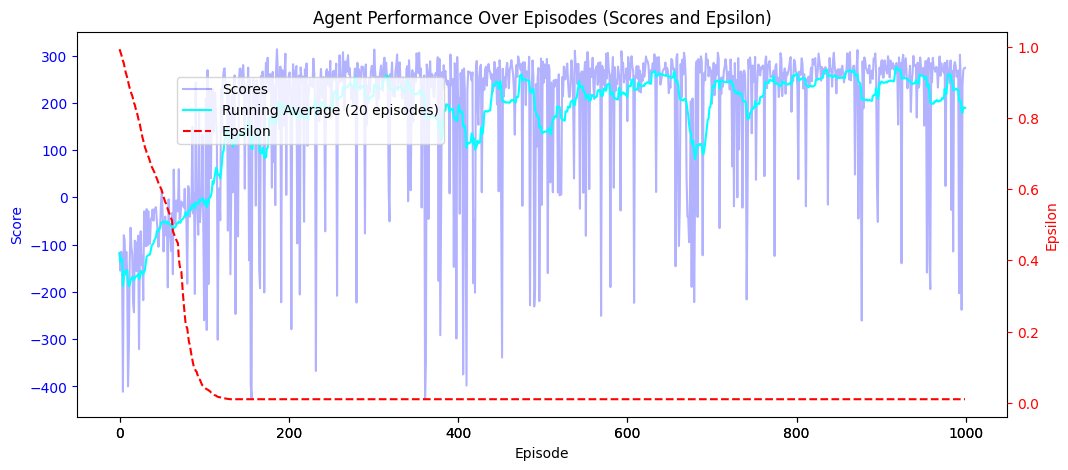

In [13]:
import matplotlib.pyplot as plt
import numpy as np

WINDOW_SIZE=20

def plot_learning_curve(scores, epsilon_history, filename):
    fig = plt.figure(figsize=(12, 5))
    ax1 = fig.add_subplot(111, label='scores')
    ax2 = fig.add_subplot(111, label='eps', frame_on=False)

    ax1.plot(scores, color='blue', label='Scores', alpha=0.3)
    ax1.set_xlabel('Episode', color='black')
    ax1.set_ylabel('Score', color='blue')
    ax1.tick_params(axis='x', colors='black')
    ax1.tick_params(axis='y', colors='blue')

    N = len(scores)
    running_avg = np.empty(N)

    for i in range(N):
        window = scores[max(0, i-WINDOW_SIZE):(i+1)]
        running_avg[i] = np.mean(window)

    ax1.plot(running_avg, color='cyan', label=f'Running Average ({WINDOW_SIZE} episodes)')

    ax2.plot(epsilon_history, color='red', label='Epsilon', linestyle='--')
    ax2.yaxis.tick_right()
    ax2.set_ylabel('Epsilon', color='red')
    ax2.yaxis.set_label_position('right')
    ax2.tick_params(axis='y', colors='red')

    plt.title('Agent Performance Over Episodes (Scores and Epsilon)')
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left', bbox_to_anchor=(0.1, 0.9))
    plt.savefig(filename)
    plt.show()

plot_learning_curve(all_scores, all_eps_history, 'lunar_lander_learning_curve.png')

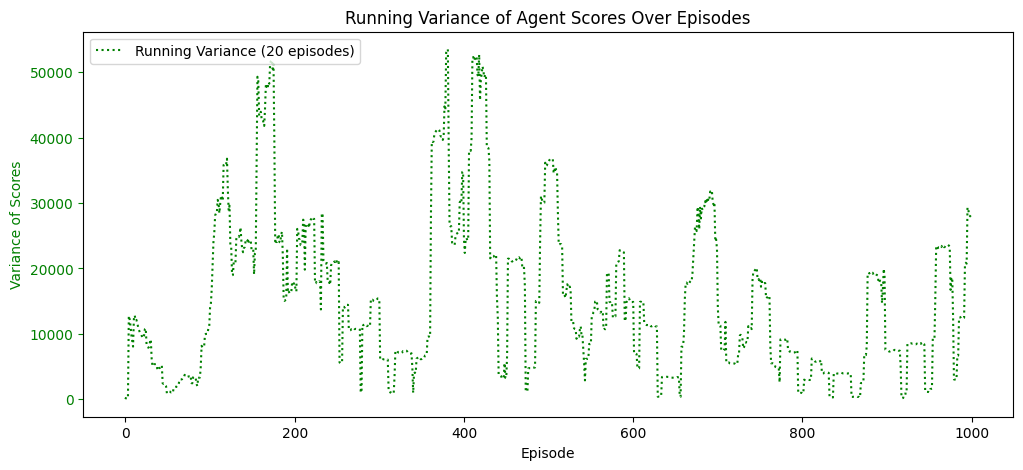

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def plot_running_variance(scores, filename):
    fig = plt.figure(figsize=(12, 5))
    ax = fig.add_subplot(111)

    N = len(scores)
    running_var = np.empty(N)

    for i in range(N):
        window = scores[max(0, i-WINDOW_SIZE):(i+1)]
        running_var[i] = np.var(window)

    ax.plot(running_var, color='green', linestyle=':', label=f'Running Variance ({WINDOW_SIZE} episodes)')
    ax.set_xlabel('Episode', color='black')
    ax.set_ylabel('Variance of Scores', color='green')
    ax.tick_params(axis='x', colors='black')
    ax.tick_params(axis='y', colors='green')

    plt.title('Running Variance of Agent Scores Over Episodes')
    plt.legend(loc='upper left')
    plt.savefig(filename)
    plt.show()

plot_running_variance(all_scores, 'lunar_lander_variance_curve.png')

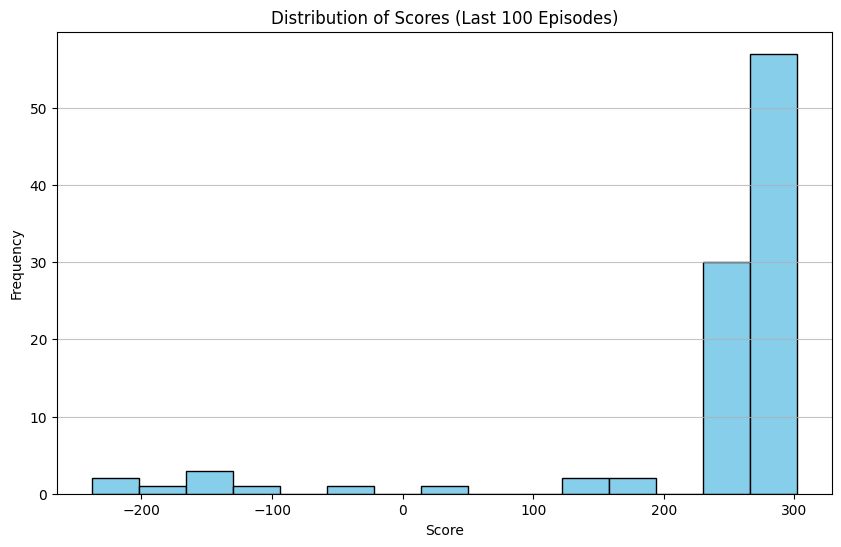

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Get scores from the last 100 episodes
last_100_scores = all_scores[-100:]

# Create the histogram
fig = plt.figure(figsize=(10, 6))
plt.hist(last_100_scores, bins=15, color='skyblue', edgecolor='black')
plt.title('Distribution of Scores (Last 100 Episodes)')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

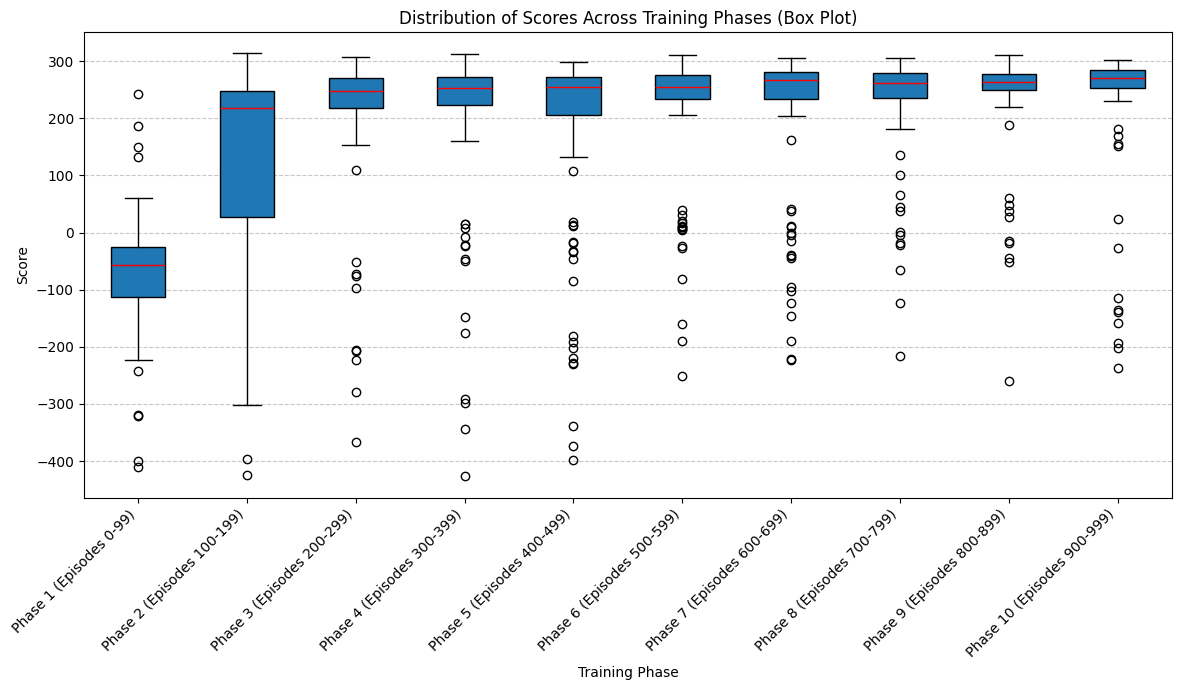

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Define the number of phases for the box plot
num_phases = len(all_scores) // 100
scores_per_phase = len(all_scores) // num_phases

# Divide scores into phases
phase_scores = []
phase_labels = []
for i in range(num_phases):
    start_idx = i * scores_per_phase
    end_idx = (i + 1) * scores_per_phase if i < num_phases - 1 else len(all_scores)
    phase_scores.append(all_scores[start_idx:end_idx])
    phase_labels.append(f'Phase {i+1} (Episodes {start_idx}-{end_idx-1})')

# Create the box plot
fig = plt.figure(figsize=(12, 7))
plt.boxplot(phase_scores, tick_labels=phase_labels, patch_artist=True, medianprops=dict(color='red'))
plt.title('Distribution of Scores Across Training Phases (Box Plot)')
plt.xlabel('Training Phase')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

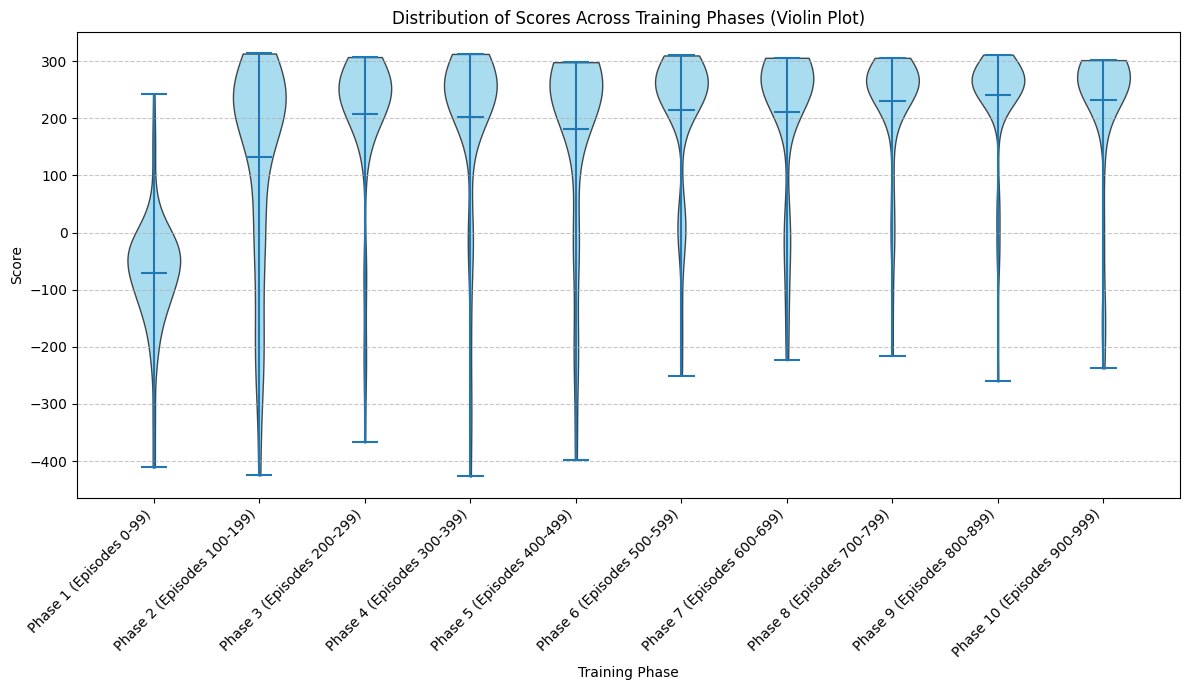

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# The variables `phase_scores` and `phase_labels` are already defined in the previous cell.

# Create the violin plot
fig = plt.figure(figsize=(12, 7))
vp = plt.violinplot(phase_scores, showmeans=True, showmedians=False, showextrema=True)

for pc in vp['bodies']:
    pc.set_facecolor('skyblue')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

plt.xticks(np.arange(1, len(phase_labels) + 1), phase_labels, rotation=45, ha='right')
plt.title('Distribution of Scores Across Training Phases (Violin Plot)')
plt.xlabel('Training Phase')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [18]:
import io
import base64
from IPython.display import HTML, display
from pathlib import Path
import re

video_dir = Path("gym-results")
files = [file for file in video_dir.iterdir()]

# Sort files by episode number
def extract_episode_number(filename):
    match = re.search(r'episode-(\d+)', str(filename))
    if match:
        return int(match.group(1))
    return -1 # Return -1 for files that don't match the pattern, placing them at the beginning

files.sort(key=extract_episode_number)

for file in files:
  print(file)

  video = io.open(file, 'r+b').read()
  encoded = base64.b64encode(video)
  display(HTML(data='''
      <video width="360" height="auto" alt="test" controls><source src="data:video/mp4;base64,{0}" type="video/mp4" /></video>'''
  .format(encoded.decode('ascii'))))

gym-results/rl-video-episode-0.mp4


gym-results/rl-video-episode-1.mp4


gym-results/rl-video-episode-8.mp4


gym-results/rl-video-episode-27.mp4


gym-results/rl-video-episode-64.mp4


...

gym-results/rl-video-episode-216.mp4


gym-results/rl-video-episode-343.mp4


gym-results/rl-video-episode-512.mp4


gym-results/rl-video-episode-729.mp4


gym-results/rl-video-episode-1000.mp4
